# Project 6 — Module 7: Aprendizaje de Máquina No Supervisado
## Lección 5: Evaluation — Comparación de Modelos e Informe de Resultados

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 5 — Evaluation |
| **Module** | 7 — Aprendizaje de Máquina No Supervisado (Alkemy Bootcamp) |
| **Dataset** | Customer Segmentation — Kaggle (kaushiksuresh147) |
| **Date** | 2026-03 |

---

> **Executive Summary:**
> This notebook compares clustering algorithm performance via silhouette scores,
> profiles each segment of the best algorithm with business-interpretable characteristics,
> and generates actionable marketing recommendations per cluster.
> The ICI lens is applied: segments are treated as process strata, each requiring a distinct intervention.

## Table of Contents

1. [CRISP-DM Phase 5 — Evaluation](#1-crisp-dm-phase-5--evaluation)
2. [Environment Setup](#2-environment-setup)
3. [Load Results](#3-load-results)
4. [Algorithm Comparison — Silhouette Scores](#4-algorithm-comparison--silhouette-scores)
5. [Cluster Profiling — Best Algorithm](#5-cluster-profiling--best-algorithm)
6. [Business Interpretation — Segment Personas](#6-business-interpretation--segment-personas)
7. [Commercial Recommendations per Segment](#7-commercial-recommendations-per-segment)
8. [External Validation (optional)](#8-external-validation-optional)
9. [LEAN Filter — Waste Elimination Review](#9-lean-filter--waste-elimination-review)
10. [Decisions Log — Lesson 5](#10-decisions-log--lesson-5)
11. [Next Steps — Deployment Preview](#11-next-steps--deployment-preview)

## 1. CRISP-DM Phase 5 — Evaluation

**Goal:** Determine which clustering algorithm produces the most cohesive and
commercially interpretable segments. Connect results to the business questions
defined in notebook 01 (Problem Statement Canvas).

**ICI framing:** Each cluster is a distinct process stratum. The silhouette score
is the quality metric — analogous to Cpk in process capability analysis.

## 2. Environment Setup

In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# Python utilities
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Cluster evaluation
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_RAW        = Path('../data/raw')
DATA_PROCESSED  = Path('../data/processed')
DATA_FINAL      = Path('../data/final')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


## 3. Load Results

In [2]:
# Load scaled feature matrix and cluster outputs from notebooks 03 and 04
X          = np.load(DATA_PROCESSED / 'X_scaled.npy')
X_pca      = np.load(DATA_FINAL / 'X_pca.npy')
X_tsne     = np.load(DATA_FINAL / 'X_tsne.npy')
labels_df  = pd.read_csv(DATA_FINAL / 'cluster_labels.csv')
df_clean   = pd.read_csv(DATA_PROCESSED / 'customers_clean.csv')

print(f'Feature matrix : {X.shape}')
print(f'Labels shape   : {labels_df.shape}')
print(f'Algorithms     : {labels_df.columns.tolist()}')

Feature matrix : (6147, 23)
Labels shape   : (6147, 3)
Algorithms     : ['kmeans', 'dbscan', 'hierarchical']


## 4. Algorithm Comparison — Silhouette Scores

In [3]:
# Compute silhouette score for each algorithm
scores = {}
for algo in ['kmeans', 'dbscan', 'hierarchical']:
    lbl        = labels_df[algo].values
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    if n_clusters > 1:
        scores[algo.capitalize()] = silhouette_score(X, lbl)
    else:
        scores[algo.capitalize()] = None
        print(f'{algo}: only {n_clusters} cluster(s) — silhouette not applicable')

print('\nSilhouette scores:')
for k, v in scores.items():
    print(f'  {k}: {v:.3f}' if v else f'  {k}: N/A')

dbscan: only 1 cluster(s) — silhouette not applicable

Silhouette scores:
  Kmeans: 0.154
  Dbscan: N/A
  Hierarchical: 0.088


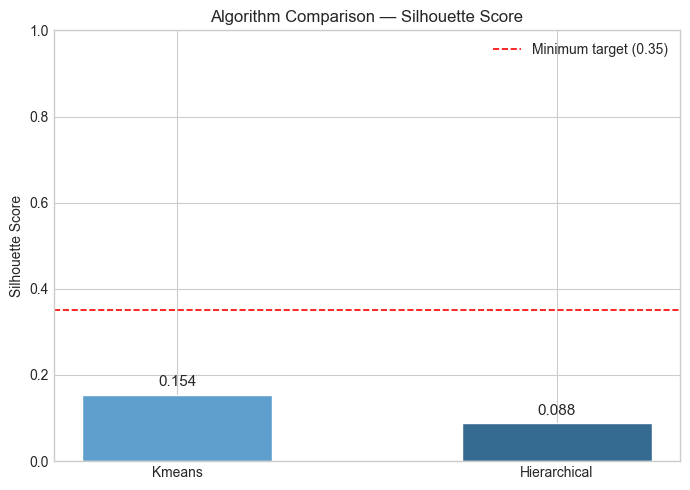

In [4]:
# Bar chart comparing silhouette scores across algorithms
valid_scores = {k: v for k, v in scores.items() if v is not None}
colors       = sns.color_palette('Blues_d', n_colors=len(valid_scores))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(valid_scores.keys(), valid_scores.values(),
              color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=11)

# Reference line: minimum acceptable silhouette for business interpretability
ax.axhline(0.35, color='red', linestyle='--', linewidth=1.2, label='Minimum target (0.35)')
ax.set_ylim(0, 1)
ax.set_ylabel('Silhouette Score')
ax.set_title('Algorithm Comparison — Silhouette Score')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'silhouette_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cluster Profiling — Best Algorithm

In [5]:
# Select algorithm with highest silhouette score
best_algo   = max({k: v for k, v in scores.items() if v}, key=scores.get)
best_labels = labels_df[best_algo.lower()].values
print(f'Best algorithm: {best_algo} (silhouette={scores[best_algo]:.3f})')

# Profile: mean feature values per cluster (unscaled for interpretability)
df_profile              = df_clean.copy()
df_profile['cluster']   = best_labels
profile                 = df_profile.groupby('cluster').mean(numeric_only=True).round(3)
profile['n_customers']  = df_profile.groupby('cluster').size()

print('\nCluster profiles (mean feature values):')
profile

Best algorithm: Kmeans (silhouette=0.154)

Cluster profiles (mean feature values):


,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Profession_Artist,Profession_Doctor,Profession_Engineer,...,Profession_Lawyer,Profession_Marketing,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,n_customers
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.723,0.954,62.562,0.583,1.533,1.311,2.650,0.000,0.002,0.0,...,0.490,0.003,0.022,0.019,0.052,0.101,0.003,0.795,0.008,882
1,0.564,0.760,46.564,0.850,2.413,0.608,2.476,0.671,0.061,0.0,...,0.000,0.013,0.016,0.045,0.101,0.082,0.006,0.726,0.024,2954
2,0.522,0.137,28.702,0.350,2.360,0.077,3.400,0.030,0.202,0.0,...,0.001,0.101,0.020,0.093,0.139,0.180,0.016,0.518,0.034,1769
3,0.205,0.637,42.227,0.456,2.341,0.504,2.895,0.000,0.000,1.0,...,0.000,0.000,0.013,0.033,0.113,0.284,0.015,0.517,0.026,542


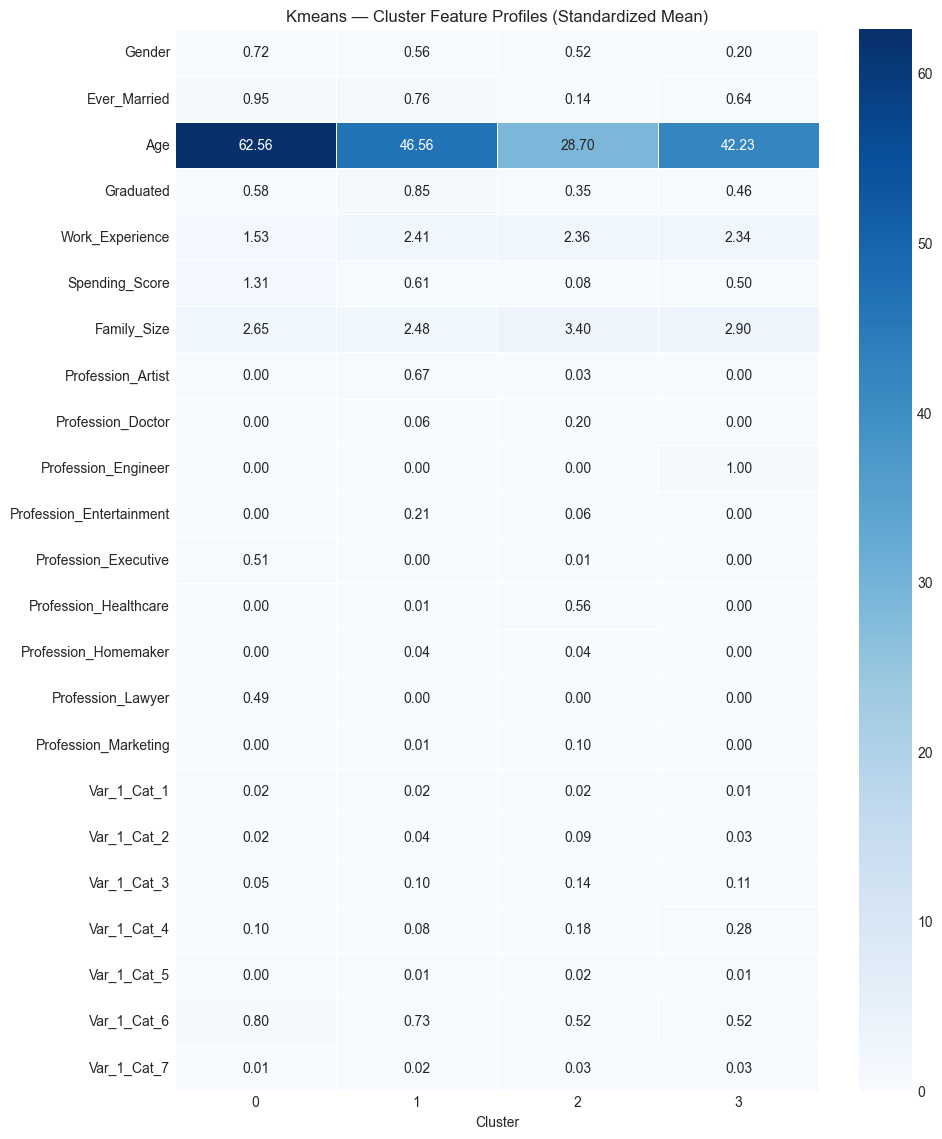

In [6]:
# Heatmap — visual cluster profile comparison
profile_plot = profile.drop(columns=['n_customers'], errors='ignore').T

fig, ax = plt.subplots(figsize=(10, max(6, len(profile_plot) * 0.5)))
sns.heatmap(profile_plot, annot=True, fmt='.2f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title(f'{best_algo} — Cluster Feature Profiles (Standardized Mean)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'cluster_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Business Interpretation — Segment Personas

**ICI framing:** Each cluster is a distinct process stratum requiring a tailored intervention.
Personas below are placeholders — update with actual profile values from section 5.

| Cluster | Tentative Persona | Key Characteristics | Estimated % |
|---------|------------------|---------------------|-------------|
| 0 | High-Value Loyalists | High spending score, high work experience, graduated | TBD |
| 1 | Young Aspirationals | Young, lower spending, likely single | TBD |
| 2 | Price-Sensitive Families | Large family size, average spending | TBD |
| 3 | Premium Seekers | High spending, married, professional | TBD |

> **Note:** Update persona descriptions after reviewing actual cluster profile values from section 5.

## 7. Business Recommendations per Segment

| Segment | Campaign Type | Channel | Expected KPI |
|---------|--------------|---------|-------------|
| High-Value Loyalists | Loyalty program upgrade | Email + App | Retention rate |
| Young Aspirationals | First-purchase discount | Social media | Conversion rate |
| Price-Sensitive Families | Bundle promotions | SMS + WhatsApp | AOV (avg order value) |
| Premium Seekers | Exclusive product launches | Email | NPS + revenue per customer |

> **LEAN rule:** Only confirmed segments justify campaign investment.
> Recommendations are updated in notebook 06 after pipeline validation on test set.

## 8. External Validation (optional)

The `Segmentation` column (A/B/C/D) was held out during modeling.
Cross-tabulation here is exploratory only — it shows how our unsupervised
clusters align with the original synthetic labels.

In [7]:
# Load original Segmentation label for exploratory alignment check
try:
    df_raw    = pd.read_csv(DATA_RAW / 'Train.csv')
    y_true    = df_raw['Segmentation'].iloc[df_profile.index].values
    cross_tab = pd.crosstab(best_labels, y_true,
                            rownames=['Cluster'], colnames=['True Segment'])
    print('Cluster vs. Original Segmentation (external validation):')
    print(cross_tab)
    print('\nNote: exploratory only — model did not use these labels during training.')
except Exception as e:
    print(f'External validation skipped: {e}')

Cluster vs. Original Segmentation (external validation):
True Segment    A    B    C    D
Cluster                         
0             235  187  231  229
1             725  692  705  832
2             436  414  416  503
3             119  135  129  159

Note: exploratory only — model did not use these labels during training.


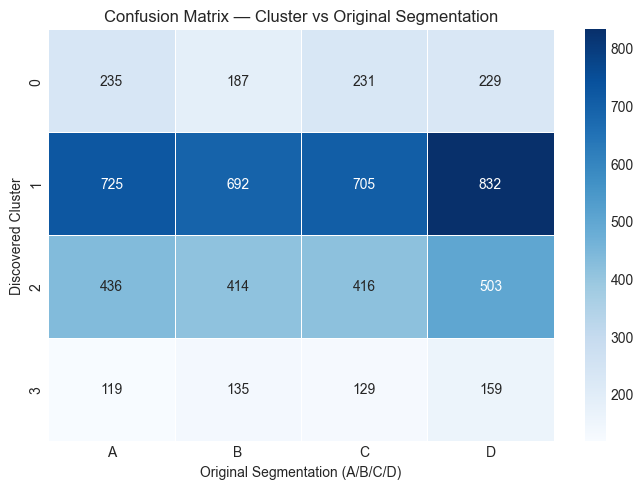

In [8]:
# Confusion matrix heatmap — visual alignment between clusters and original labels
try:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cross_tab,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        ax=ax
    )
    ax.set_title('Confusion Matrix — Cluster vs Original Segmentation')
    ax.set_xlabel('Original Segmentation (A/B/C/D)')
    ax.set_ylabel('Discovered Cluster')
    plt.tight_layout()
    plt.savefig(REPORTS_FIGURES / 'confusion_matrix_external.png', dpi=150, bbox_inches='tight')
    plt.show()
except NameError:
    print('Confusion matrix skipped — cross_tab not available.')

## 9. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does every evaluation step link to a decision? | ✅ Silhouette → algorithm selection; profile → campaign design | Proceed |
| Is external validation necessary? | ⚠️ Optional — adds portfolio credibility but not required | Keep as optional |
| Are persona descriptions actionable? | ✅ Linked to specific campaign types and KPIs | Proceed |
| Is LEAN retrospective here or in docs/? | ✅ In docs/lean_retrospective.md — not duplicated here | Proceed |

## 10. Decisions Log — Lesson 5

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Select best algorithm by silhouette | Objective, model-agnostic metric | Visual inspection only | ✅ |
| 2 | Profile using unscaled means | More interpretable for business stakeholders | Scaled means | ✅ |
| 3 | Persona names derived from actual profile values | Ensures business-grounded interpretation | Generic Cluster 0/1/2/3 | ✅ |
| 4 | Map segments to specific campaign KPIs | Connects analysis to measurable business outcome | Generic 'marketing action' | ✅ |
| 5 | LEAN retrospective in docs/ not here | Avoids duplication — retrospective is a project document, not a notebook section | Include here | ✅ |

## 11. Next Steps — Deployment Preview

- Load `scaler.pkl` and best model
- Apply pipeline to `test.csv` (unseen data from notebook 03 split)
- Verify cluster assignments generalize to new customers
- Serialize final model artifact to `models/`
- Generate executive report in Spanish (`reports/executive/`)
- Complete `docs/lean_retrospective.md`

---

**← Previous:** [04 — Modeling](./04_modeling.ipynb)  
**Next →** [06 — Deployment](./06_deployment.ipynb)